In [41]:
import matplotlib.pyplot as plt
import datajoint as dj
import numpy as np

import spyglass.common as sgc
from spyglass.decoding.decoding_merge import DecodingOutput

from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock
from spyglass_hexmaze.hex_maze_decoding import (
    HexMazeDecodedPosition,
    HexMazeDecodedPositionHex,
    HexMazeDecodedHexPath,
)

from hexmaze import plot_hex_maze

# Make sure the session exists in the hex maze tables
nwb_file_name = "Toby20250316_.nwb"
key = {"nwb_file_name": nwb_file_name}

display(HexMazeBlock() & key)
df = (HexMazeDecodedHexPath & key).fetch1_dataframe()


nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),block the block number within the epoch,config_id maze configuration as a string,interval_list_name descriptive name of this interval list,p_a probability of reward at port A,p_b probability of reward at port B,p_c probability of reward at port C,num_trials number of trials in this block,task_type 'barrier shift' or 'probabilty shift'
Toby20250316_.nwb,1,1,"10,12,18,21,25,28,34,37,42,45",epoch1_block1,50.0,90.0,10.0,69,probability change
Toby20250316_.nwb,1,2,"10,12,18,21,25,28,34,37,42,45",epoch1_block2,50.0,10.0,90.0,69,probability change
Toby20250316_.nwb,1,3,"10,12,18,21,25,28,34,37,42,45",epoch1_block3,90.0,50.0,10.0,69,probability change
Toby20250316_.nwb,3,1,"8,9,11,17,20,23,31,34,38,46",epoch3_block1,10.0,50.0,90.0,52,barrier change
Toby20250316_.nwb,3,2,"8,9,11,20,23,30,31,34,38,46",epoch3_block2,10.0,50.0,90.0,70,barrier change
Toby20250316_.nwb,3,3,"8,9,11,16,23,30,31,34,38,46",epoch3_block3,10.0,50.0,90.0,44,barrier change
Toby20250316_.nwb,3,4,"8,9,11,16,26,30,31,34,38,46",epoch3_block4,10.0,50.0,90.0,40,barrier change
Toby20250316_.nwb,3,5,"8,9,11,16,24,26,31,34,38,46",epoch3_block5,10.0,50.0,90.0,10,barrier change
Toby20250316_.nwb,5,1,"7,10,19,21,22,24,35,42,43,46",epoch5_block1,90.0,10.0,50.0,69,probability change
Toby20250316_.nwb,5,2,"7,10,19,21,22,24,35,42,43,46",epoch5_block2,50.0,90.0,10.0,69,probability change


<Axes: title={'center': 'Decode distance over trials'}, xlabel='Trial', ylabel='Decode hex distance'>

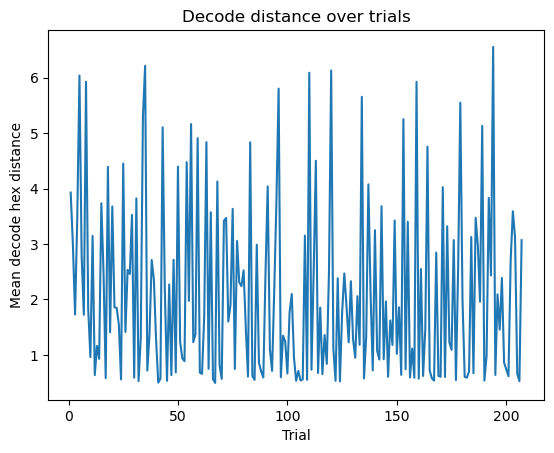

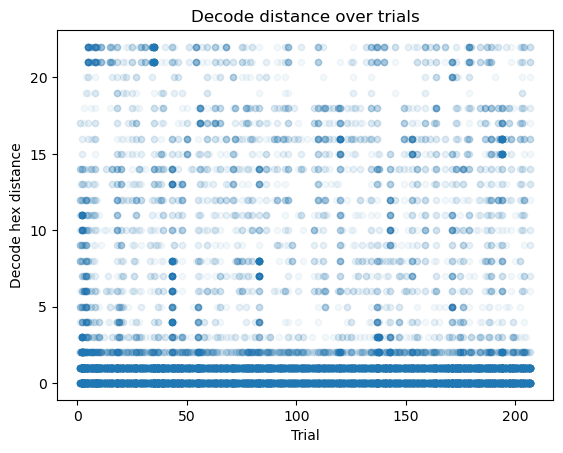

In [42]:
# Average decode-actual hex distance per trial
trial_dist = df.groupby("epoch_trial_num")["decode_hex_distance"].mean()

trial_dist.plot(xlabel="Trial", ylabel="Mean decode hex distance", title="Decode distance over trials")

df.plot.scatter(x="epoch_trial_num", y="decode_hex_distance", alpha=0.05,
                xlabel="Trial", ylabel="Decode hex distance",
                title="Decode distance over trials")



<Axes: title={'center': 'Decode distance by maze section'}, xlabel='maze_portion', ylabel='Mean decode hex distance'>

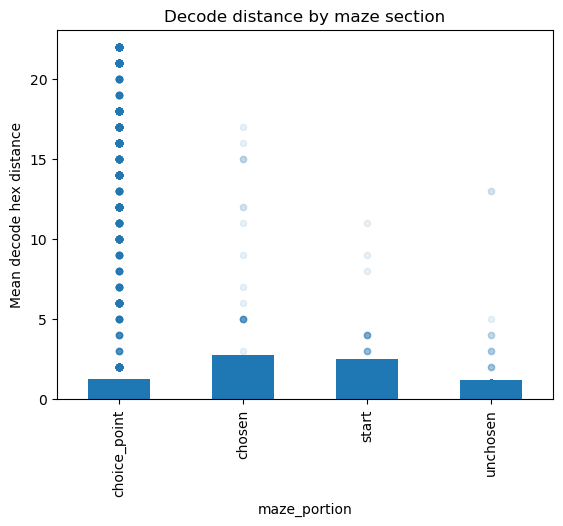

In [43]:
# How far is the decode when the animal is near vs far from the end port?
df.plot.scatter(x="hexes_from_end", y="decode_hex_distance", alpha=0.1,
                xlabel="Actual hexes from end port", ylabel="Decode hex distance")

# Or grouped by maze portion
df.groupby("maze_portion")["decode_hex_distance"].mean().plot.bar(
    ylabel="Mean decode hex distance", title="Decode distance by maze section")


<Axes: title={'center': 'Where does the decoder represent?'}, xlabel='maze_portion', ylabel='Proportion of decode time'>

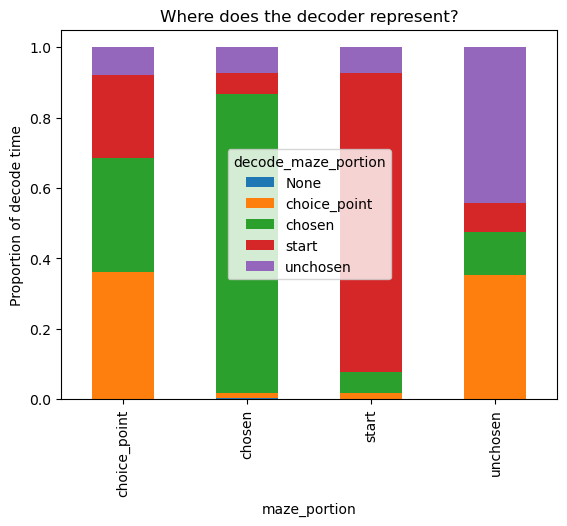

In [35]:
# How often does the decode land in each maze section?
decode_counts = df.groupby(["maze_portion", "decode_maze_portion"]).size().unstack(fill_value=0)
# Normalize to proportions per actual maze portion
decode_props = decode_counts.div(decode_counts.sum(axis=1), axis=0)
decode_props.plot.bar(stacked=True, ylabel="Proportion of decode time",
                      title="Where does the decoder represent?")


<Axes: xlabel='Trial', ylabel='Fraction decode in unchosen arm'>

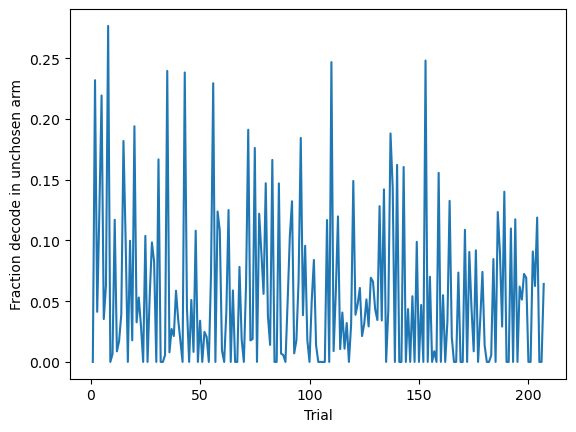

In [44]:
# Fraction of time decode is in unchosen arm, per trial
unchosen_by_trial = (
    df.groupby("epoch_trial_num")["decode_maze_portion"]
    .apply(lambda x: (x == "unchosen").mean())
)
unchosen_by_trial.plot(xlabel="Trial", ylabel="Fraction decode in unchosen arm")


<Axes: title={'center': 'Decode location when at choice point'}, xlabel='decode_maze_portion', ylabel='Proportion'>

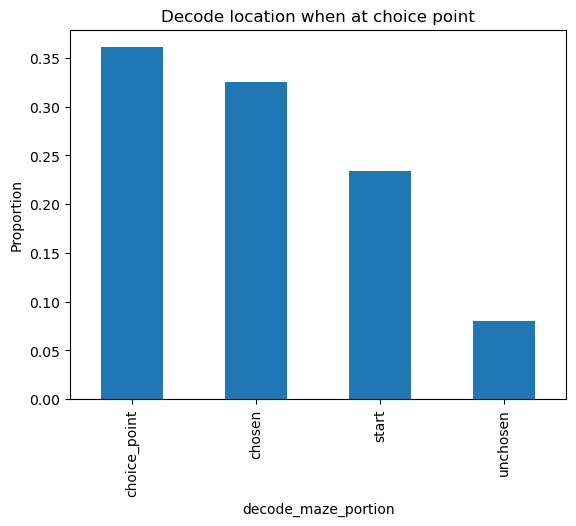

In [45]:
# When the animal is at a choice point, where does decode point?
at_choice = df[df["maze_portion"] == "choice_point"]
at_choice["decode_maze_portion"].value_counts(normalize=True).plot.bar(
    ylabel="Proportion", title="Decode location when at choice point")


<Axes: title={'center': 'Decode distance approaching choice point'}, xlabel='Hexes from start port (closer to choice point →)', ylabel='Mean decode hex distance'>

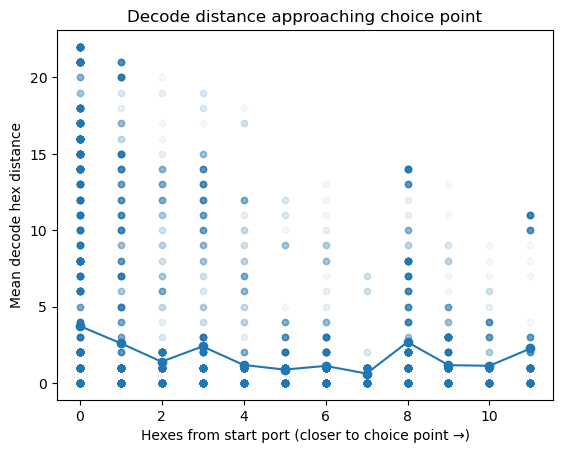

In [46]:
# Filter to segments where the animal is approaching the choice point (in the start arm)
approach = df[df["maze_portion"] == "start"].copy()

# Simpler: just plot decode_hex_distance vs hexes_from_start (further from start = closer to choice point)
approach.plot.scatter(x="hexes_from_start", y="decode_hex_distance", alpha=0.05,
                      xlabel="Hexes from start port (closer to choice point →)",
                      ylabel="Decode hex distance",
                      title="Decode distance approaching choice point")


approach.groupby("hexes_from_start")["decode_hex_distance"].mean().plot(
    marker="o",
    xlabel="Hexes from start port (closer to choice point →)",
    ylabel="Mean decode hex distance",
    title="Decode distance approaching choice point")
